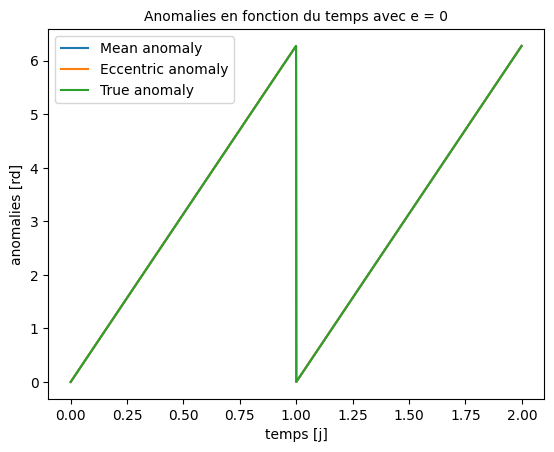

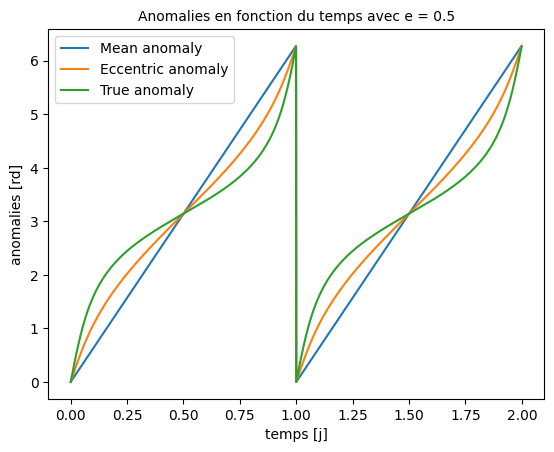

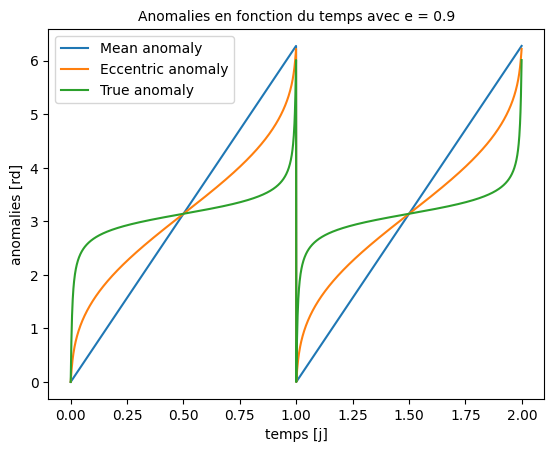

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Le but est de regarder les différences entres anomalies
# M: Mean Anomaly
# E:Excentric Anomaly
# v: True Anomaly

def Anomalies(e, t_Revolution, t_Init, t_End, h):


    # On prend en entree l'eccentricite, le temps de revolution, le temps auquel on debute et finit l observation
    # ainsi que le pas entre les mesures

    Temps                = []
    Mean_anomaly         = []
    True_anomaly         = []
    Eccentric_anomaly    = []
    t1                   = t_Init
    
    for t in np.arange(t_Init, t_End, h):
                
        t1 = t1 + h
        if t > t_Revolution:
            t1 = t_Init
            
        # calcul de M en fonction du temps
        # M = n * (t - t0)

        # avec                 n            = sqrt(mu / a^3)
        # 3ieme loi de Kepler: t_Revolution = 2 * pi * sqrt(a^3 / mu)
        # =>                   n            = 2 * pi / t_Revolution

        M = (2 * np.pi / t_Revolution) * (t% t_Revolution- t_Init)  

        if M > 2 * np.pi:
            M = M - 2 * np.pi
        elif M < 0:
            M = M + 2 * np.pi


        # Init E egale à M            
        E = M

        # Equation de Kepler
        # M = E − e * sin(E)      =>      E = M + e * sin(E)

        # Excentricity =  0, pas de différene entre les anomalies
        if e == 0:
            E = M


        else:
            for k in range(0,10,1):

                # Taylor development :
                # E_i+1 = M + e * sin(E_ i)
                # E = M + e * np.sin(E)

                # ou 

                # Newton algorithm:
                # f(E) = E − e sin(E) − M
                # E_i+1 = E_1 - f(E_i) / f'(E_i)
                E = E - (E - e * np.sin(E) -M) / (1 - e * np.cos(E))
  
        
        # Calcul True Anomaly en fonction de E
        v = 2 * np.arctan( np.sqrt((1+e)/(1-e)) * np.tan(E/2))

        # Attention aux bornes
        if v < 0:
            v = v + 2 * np.pi

        elif v > 2 * np.pi:
            v = v - 2 * np.pi

        # Stockage des anomalies       
        Mean_anomaly.append(M)
        Eccentric_anomaly.append(E)
        True_anomaly.append(v)
        Temps.append(t)       
 
    return [Temps, Mean_anomaly, Eccentric_anomaly, True_anomaly]



T,M,E,V     = Anomalies(0,   1, 0, 2, 0.001)
T1,M1,E1,V1 = Anomalies(0.5, 1, 0, 2, 0.001)
T2,M2,E2,V2 = Anomalies(0.9, 1, 0, 2, 0.001)

import matplotlib.pyplot as plt

# Création d'une figure avec 3 sous-plots
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Plot pour e = 0
axes[0].set_title('Anomalies en fonction du temps avec e = 0', fontsize=10)
axes[0].set_ylabel('anomalies [rd]')
axes[0].plot(T, M, label='Mean anomaly')
axes[0].plot(T, E, label='Eccentric anomaly')
axes[0].plot(T, V, label='True anomaly')
axes[0].legend()

# Plot pour e = 0.5
axes[1].set_title('Anomalies en fonction du temps avec e = 0.5', fontsize=10)
axes[1].set_ylabel('anomalies [rd]')
axes[1].plot(T1, M1, label='Mean anomaly')
axes[1].plot(T1, E1, label='Eccentric anomaly')
axes[1].plot(T1, V1, label='True anomaly')
axes[1].legend()

# Plot pour e = 0.9
axes[2].set_title('Anomalies en fonction du temps avec e = 0.9', fontsize=10)
axes[2].set_xlabel('temps [j]')
axes[2].set_ylabel('anomalies [rd]')
axes[2].plot(T2, M2, label='Mean anomaly')
axes[2].plot(T2, E2, label='Eccentric anomaly')
axes[2].plot(T2, V2, label='True anomaly')
axes[2].legend()

# Ajustement de l'affichage
plt.tight_layout()
plt.show()